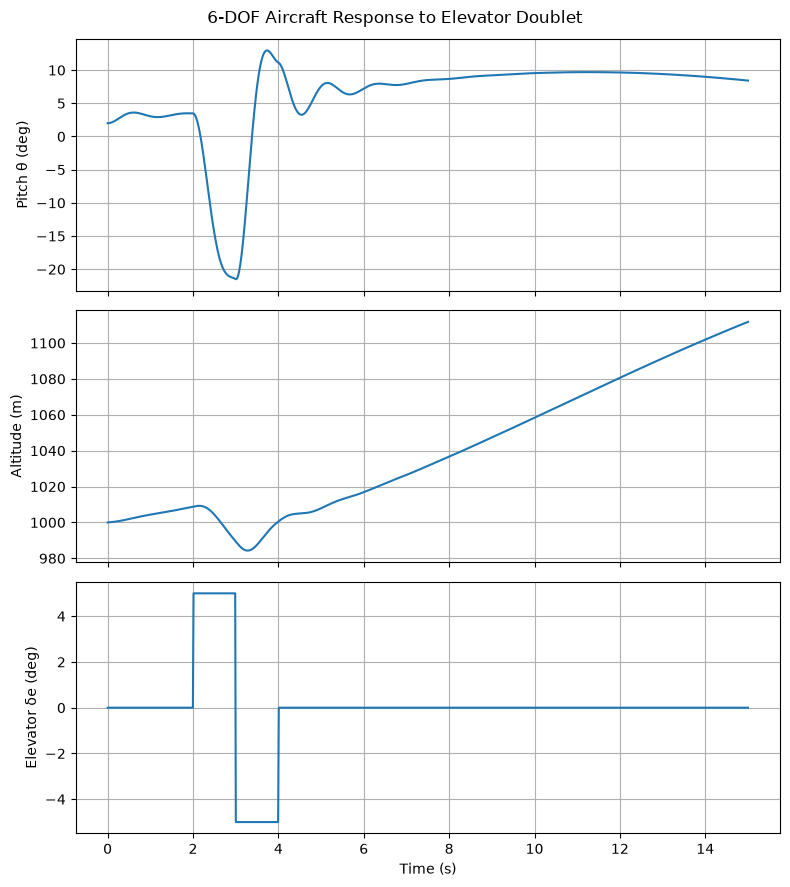

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- Aircraft mass/inertia properties ---
mass = 1200.0                          # kg
Ixx, Iyy, Izz = 1285., 1825., 2667.    # kg*m^2 (diagonal inertia, no cross-products)
S = 16.2                                # wing reference area, m^2
c_bar = 1.49                            # mean aerodynamic chord, m
g = 9.81

# --- Linear aerodynamic model coefficients (typical light aircraft) ---
CL0, CL_alpha = 0.28, 5.0        # lift coefficient, per rad
CD0, k_induced = 0.03, 0.045     # drag polar: CD = CD0 + k*CL^2
Cm0, Cm_alpha, Cm_de = 0.02, -1.1, -1.8   # pitching moment, per rad

def atmosphere_density(altitude):
    """Simple exponential atmosphere."""
    return 1.225 * np.exp(-max(altitude, 0) / 8500.0)

def elevator_doublet(t):
    """Classic flight-test input to excite short-period pitch dynamics."""
    de = np.radians(5)
    if 2.0 <= t < 3.0:
        return de
    elif 3.0 <= t < 4.0:
        return -de
    return 0.0

def aero_forces_moments(state, t):
    u, v, w, p, q, r, phi, theta, psi, x, y, z = state
    altitude = z
    V = max(np.sqrt(u**2 + v**2 + w**2), 1.0)
    alpha = np.arctan2(w, u)            # angle of attack
    rho = atmosphere_density(altitude)
    Q = 0.5 * rho * V**2                 # dynamic pressure

    de = elevator_doublet(t)

    CL = CL0 + CL_alpha * alpha
    CD = CD0 + k_induced * CL**2
    Cm = Cm0 + Cm_alpha * alpha + Cm_de * de

    L = Q * S * CL
    D = Q * S * CD
    M = Q * S * c_bar * Cm

    # Wind axes -> body axes
    Fx = -D * np.cos(alpha) + L * np.sin(alpha) + 2200.0  # + thrust, N
    Fz = -D * np.sin(alpha) - L * np.cos(alpha)
    Fy = 0.0

    return Fx, Fy, Fz, 0.0, M, 0.0

def eom(t, state):
    u, v, w, p, q, r, phi, theta, psi, x, y, z = state
    Fx, Fy, Fz, L, M, N = aero_forces_moments(state, t)

    gx = -g * np.sin(theta)
    gy =  g * np.sin(phi) * np.cos(theta)
    gz =  g * np.cos(phi) * np.cos(theta)

    du = r*v - q*w + Fx/mass + gx
    dv = p*w - r*u + Fy/mass + gy
    dw = q*u - p*v + Fz/mass + gz

    dp = (L + (Iyy - Izz)*q*r) / Ixx
    dq = (M + (Izz - Ixx)*p*r) / Iyy
    dr = (N + (Ixx - Iyy)*p*q) / Izz

    dphi   = p + np.tan(theta)*(q*np.sin(phi) + r*np.cos(phi))
    dtheta = q*np.cos(phi) - r*np.sin(phi)
    dpsi   = (q*np.sin(phi) + r*np.cos(phi)) / np.cos(theta) if abs(np.cos(theta)) > 1e-6 else 0.0

    dx = u*np.cos(theta)*np.cos(psi) - w*np.sin(theta)
    dy = u*np.cos(theta)*np.sin(psi)
    dz = u*np.sin(theta) + w*np.cos(theta)

    return [du, dv, dw, dp, dq, dr, dphi, dtheta, dpsi, dx, dy, dz]

# Level flight at 60 m/s, 1000 m altitude, 2 deg pitch trim
state0 = [60, 0, 0, 0, 0, 0, 0, np.radians(2), 0, 0, 0, 1000]

sol = solve_ivp(eom, [0, 15], state0, max_step=0.02, dense_output=True, rtol=1e-8, atol=1e-8)

t = np.linspace(0, 15, 1000)
y = sol.sol(t)

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
axs[0].plot(t, np.degrees(y[7])); axs[0].set_ylabel('Pitch θ (deg)'); axs[0].grid(True)
axs[1].plot(t, y[11]); axs[1].set_ylabel('Altitude (m)'); axs[1].grid(True)
axs[2].plot(t, [np.degrees(elevator_doublet(ti)) for ti in t])
axs[2].set_ylabel('Elevator δe (deg)'); axs[2].set_xlabel('Time (s)'); axs[2].grid(True)
fig.suptitle('6-DOF Aircraft Response to Elevator Doublet')
plt.tight_layout()
plt.show()